## Author: Meena Anwar
Lab learns wine quality dataset using decision trees algorithm.



## Setup

In [ ]:
# data pre-processing
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler

# data mining
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, r2_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

# visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib

## Data pre-processing: Wine quality dataset
In this lab, you will use the wine quality dataset from the UCI repository: https://archive.ics.uci.edu/ml/datasets/Wine+Quality


**Input variables (based on physicochemical tests):**  
1 - fixed acidity  
2 - volatile acidity  
3 - citric acid  
4 - residual sugar  
5 - chlorides  
6 - free sulfur dioxide  
7 - total sulfur dioxide  
8 - density  
9 - pH  
10 - sulphates  
11 - alcohol  

**Output variable (based on sensory data):**  
12 - quality (score between 0 and 10)  


We are going to classify 'quality' based on features in the dataset.

In [ ]:
wine = pd.read_csv("./winequality-red.csv")
#loads the wine dataset from the csv file and stores it in a pandas DataFrame called
wine
#shows all columns and rows of the wine dataset

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,11.6,0.580,0.66,2.20,0.074,10.0,47.0,1.00080,3.25,0.57,9.0,3
1,10.4,0.610,0.49,2.10,0.200,5.0,16.0,0.99940,3.16,0.63,8.4,3
2,7.4,1.185,0.00,4.25,0.097,5.0,14.0,0.99660,3.63,0.54,10.7,3
3,10.4,0.440,0.42,1.50,0.145,34.0,48.0,0.99832,3.38,0.86,9.9,3
4,8.3,1.020,0.02,3.40,0.084,6.0,11.0,0.99892,3.48,0.49,11.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,8.6,0.420,0.39,1.80,0.068,6.0,12.0,0.99516,3.35,0.69,11.7,8
1595,5.5,0.490,0.03,1.80,0.044,28.0,87.0,0.99080,3.50,0.82,14.0,8
1596,7.2,0.330,0.33,1.70,0.061,3.0,13.0,0.99600,3.23,1.10,10.0,8
1597,7.2,0.380,0.31,2.00,0.056,15.0,29.0,0.99472,3.23,0.76,11.3,8


In [ ]:
wine.dtypes
#displays the data types of each variable in the wine dataset

fixed_acidity           float64
volatile_acidity        float64
citric_acid             float64
residual_sugar          float64
chlorides               float64
free_sulfur_dioxide     float64
total_sulfur_dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

In [ ]:
wine.quality = wine.quality.replace(3, 0)
#replaces the quality ratings of 3 with 0 in the wine dataset, low quality
wine.quality = wine.quality.replace(4, 0)
#replaces the quality ratings of 4 with 0 in the wine dataset
wine.quality = wine.quality.replace(5, 0)
#replaces the quality ratings of 5 with 0 in the wine dataset
wine.quality = wine.quality.replace(6, 0)
#replaces the quality ratings of 6 with 0 in the wine dataset
wine.quality = wine.quality.replace(7, 1)
#replaces the quality ratings of 7 with 1 in the wine dataset, high quality
wine.quality = wine.quality.replace(8, 1)
#replaces the quality ratings of 8 with 1 in the wine dataset
wine.quality = wine.quality.replace(9, 1)
#replaces the quality ratings of 9 with 1 in the wine dataset
wine.quality = wine.quality.replace(10, 1)
#replaces the quality ratings of 10 with 1 in the wine dataset

In [ ]:
X = np.array(pd.DataFrame(wine, columns=['fixed_acidity','volatile_acidity', 'residual_sugar', 'density','pH','alcohol']))
#selects the indepentant variable and converts it into a numpy array called X
y = np.array(pd.DataFrame(wine, columns=['quality']))
#selects the dependent variable and converts it into a numpy array called y

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y)
#splits the dataset into training and testing sets, with X_train and y_train for training, and X_test and y_test for testing

In [ ]:
normalizer = StandardScaler()
#creates a scaler object to standardize the features by removing the mean and scaling to unit variance
X_train = normalizer.fit_transform(X_train)
#fit the scaler on training data and then transform the training data using the fitted scaler, standardizing the features in X_train
X_test = normalizer.fit_transform(X_test)
#transforms the test data. standardizing the features in X_test using the same scaler fitted on the training data

### 2. How many instances do you have for test? 

In [ ]:
# the wine dataset has 1599 observations. Since train_test_split by default splits the data into 75% training and 25% testing, there are approximately 1200 observations in the training set and
# 400 observations in the testing set.

### 3. Can you say that the dataset is imbalanced? Justify your answer.

In [ ]:
# the dataset is imbalanced because there are more observations of low quality wines (quality ratings of 3, 4, 5, and 6) than high quality wines (quality ratings of 7, 8, 9, and 10). This imbalance can lead to a bias in the model's predictions towards the majority class (low quality wines) and may result in poor performance when predicting the minority class (high quality wines).
#since one class is much larger than the other, the data set is imbalanced. This can lead to a bias in the model's predictions towards the majority class (low quality wines) and may result in poor performance when predicting the minority class (high quality wines). 

## Learn a model and model evaluation

### 4. Develop a decision tree when max_depth = None
(1) Train a model

(2) Test the model and evaluate it in terms of Accuracy and confusion matrix

(3) Visualize the model (Note: not decision boundary but the tree... you can't generate a boundary)

(4) What is the depth of the tree?

In [12]:
# 1: train model
model = DecisionTreeClassifier(max_depth=None)
model.fit(X_train, y_train)

DecisionTreeClassifier()

In [ ]:
#2: evaluate model and test
y_pred = model.predict(X_test)  
accuracy = accuracy_score(y_test, y_pred)  
print("Accuracy:", accuracy)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))  
print("Classification Report:")
print(classification_report(y_test, y_pred))  

Accuracy: 0.855
Confusion Matrix:
[[309  33]
 [ 25  33]]
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.90      0.91       342
           1       0.50      0.57      0.53        58

    accuracy                           0.85       400
   macro avg       0.71      0.74      0.72       400
weighted avg       0.86      0.85      0.86       400



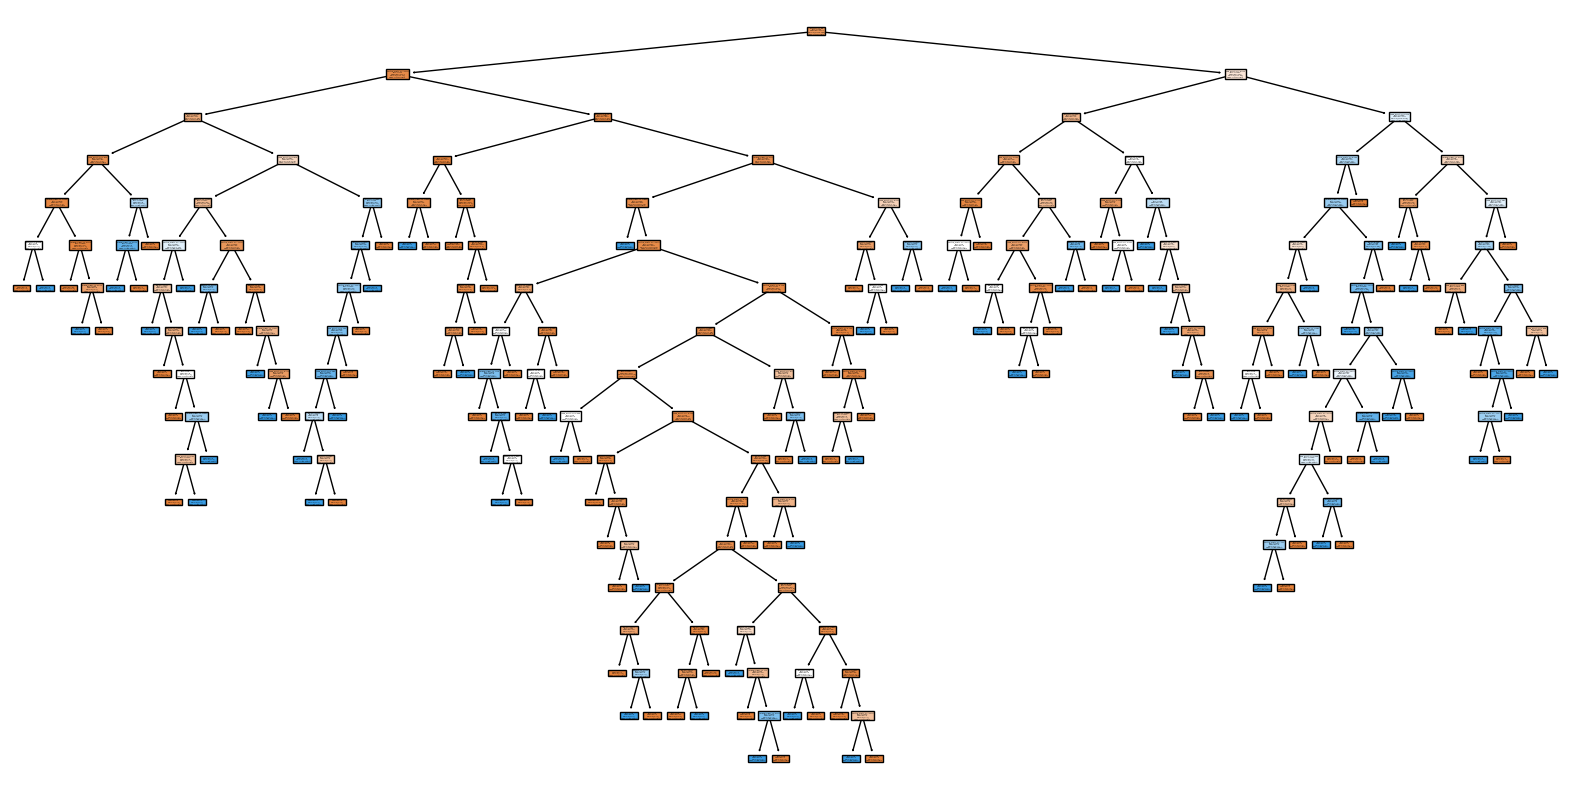

In [ ]:
#3: visualize model
plt.figure(figsize=(20,10))
plot_tree(model,
          feature_names=['fixed_acidity','volatile_acidity','residual_sugar','density','pH','alcohol'],
          class_names=['Low Quality','High Quality'],
          filled=True) 
plt.show()

In [ ]:
#4: depth of tree
print("Tree Depth:", model.get_depth())

Tree Depth: 17


### 5. Copy and paste the code you compose above. Vary max_depth value (trial-and-error) to find the optimal depth that avoids model overfit. Justify your choice.


In [21]:
for depth in range(1, 21):
    # train model
    model = DecisionTreeClassifier(max_depth=depth)
    model.fit(X_train, y_train)
    # test model
    y_pred = model.predict(X_test)
    # evaluate model
    accuracy = accuracy_score(y_test, y_pred)
    print("Depth:", depth)
    print("Accuracy:", accuracy)
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

Depth: 1
Accuracy: 0.855
Confusion Matrix:
[[342   0]
 [ 58   0]]
Depth: 2
Accuracy: 0.865
Confusion Matrix:
[[332  10]
 [ 44  14]]
Depth: 3
Accuracy: 0.865
Confusion Matrix:
[[338   4]
 [ 50   8]]
Depth: 4
Accuracy: 0.8575
Confusion Matrix:
[[319  23]
 [ 34  24]]
Depth: 5
Accuracy: 0.8575
Confusion Matrix:
[[321  21]
 [ 36  22]]
Depth: 6
Accuracy: 0.865
Confusion Matrix:
[[319  23]
 [ 31  27]]
Depth: 7
Accuracy: 0.8725
Confusion Matrix:
[[319  23]
 [ 28  30]]
Depth: 8
Accuracy: 0.8725
Confusion Matrix:
[[316  26]
 [ 25  33]]
Depth: 9
Accuracy: 0.8725
Confusion Matrix:
[[316  26]
 [ 25  33]]
Depth: 10
Accuracy: 0.86
Confusion Matrix:
[[313  29]
 [ 27  31]]
Depth: 11
Accuracy: 0.87
Confusion Matrix:
[[315  27]
 [ 25  33]]
Depth: 12
Accuracy: 0.86
Confusion Matrix:
[[311  31]
 [ 25  33]]
Depth: 13
Accuracy: 0.8525
Confusion Matrix:
[[308  34]
 [ 25  33]]
Depth: 14
Accuracy: 0.8725
Confusion Matrix:
[[314  28]
 [ 23  35]]
Depth: 15
Accuracy: 0.8625
Confusion Matrix:
[[311  31]
 [ 24  34]]

### 6. Browse the help page of the function 'DecisionTreeClassifier'. (1) Which measure is used as a measure of node impurity by default? (2) Is it appropriate to use the default for the given data? Justify your answer.

In [ ]:
#1. The default measure of node impurity is gini.
#2. Yes, it is appropriate to use the default gini impurity for the given data.
# gini impurity measures how pure each node is after a split. Since we are classifying wines into two classes, using the default gini measure is suitable for this dataset
